In [1]:
!git clone https://github.com/Franck-Dernoncourt/pubmed-rct.git
!ls pubmed-rct


Cloning into 'pubmed-rct'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 39 (delta 8), reused 5 (delta 5), pack-reused 25 (from 1)
Receiving objects: 100% (39/39), 177.08 MiB | 37.27 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Updating files: 100% (13/13), done.
PubMed_200k_RCT
PubMed_200k_RCT_numbers_replaced_with_at_sign
PubMed_20k_RCT
PubMed_20k_RCT_numbers_replaced_with_at_sign
README.md


In [2]:
!ls pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign

dev.txt  test.txt  train.txt


In [3]:
data_dir = '/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign'

In [4]:
import os
filenames = [data_dir + filename for filename in os.listdir(data_dir)]
filenames

['/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_signdev.txt',
 '/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_signtrain.txt',
 '/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_signtest.txt']

In [5]:
def get_lines(filename):
  with open(filename, 'r') as f:
    return f.readlines()

In [6]:
#import zipfile
#zip_ref = zipfile.ZipFile('/content/pubmed-rct/PubMed_200k_RCT_numbers_replaced_with_at_sign/train.zip', "r")
#zip_ref.extractall()
#zip_ref.close()

train_lines = get_lines( '/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt')
train_lines[:20]

['###24293578\n',
 'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n',
 'METHODS\tA total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .\n',
 'METHODS\tOutcome measures included pain reduction and improvement in function scores and systemic inflammation markers .\n',
 'METHODS\tPain was assessed using the visual analog pain scale ( @-@ mm ) .\n',
 'METHODS\tSecondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and @-min walk distance ( @MWD ) .\n',
 'METHODS\tSerum levels of interleukin @ ( IL-@ ) , IL-@ , tumor necrosis factor ( TNF ) - , and 

In [7]:
def preprocess_text_with_line_numbers(filename):
  input_lines = get_lines(filename)
  abstract_lines = ''
  abstract_samples = []

  for line in input_lines:
    if line.startswith('###'):
      abstract_id = line
      abstract_lines = ''
    elif line.isspace():
      abstract_line_split = abstract_lines.splitlines()
      for abstract_line_number, abstract_line in enumerate(abstract_line_split):
        line_data={}
        target_text_split = abstract_line.split('\t')
        line_data['target'] = target_text_split[0]
        line_data['text'] = target_text_split[1].lower()
        line_data['line_number'] = abstract_line_number
        line_data['total_lines'] = len(abstract_line_split) - 1
        abstract_samples.append(line_data)
    else:
      abstract_lines += line

  return abstract_samples

In [8]:
%%time
train_samples = preprocess_text_with_line_numbers('/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt')
val_samples = preprocess_text_with_line_numbers('/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/dev.txt')
test_samples = preprocess_text_with_line_numbers('/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/test.txt')
len(train_samples), len(val_samples), len(test_samples)

CPU times: user 573 ms, sys: 90 ms, total: 662 ms
Wall time: 993 ms


(180040, 30212, 30135)

In [9]:
train_samples[:12]

[{'target': 'OBJECTIVE',
  'text': 'to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
  'line_number': 0,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
  'line_number': 1,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
  'line_number': 2,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
  'line_number': 3,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'secondary outcome measures included the western ontari

In [10]:
import pandas as pd

train_df= pd.DataFrame(train_samples)
val_df = pd.DataFrame(val_samples)
test_df = pd.DataFrame(test_samples)

train_df.head(4)

,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11


In [11]:
train_df.target.value_counts()

,count
target,
METHODS,59353
RESULTS,57953
CONCLUSIONS,27168
BACKGROUND,21727
OBJECTIVE,13839


<Axes: ylabel='Frequency'>

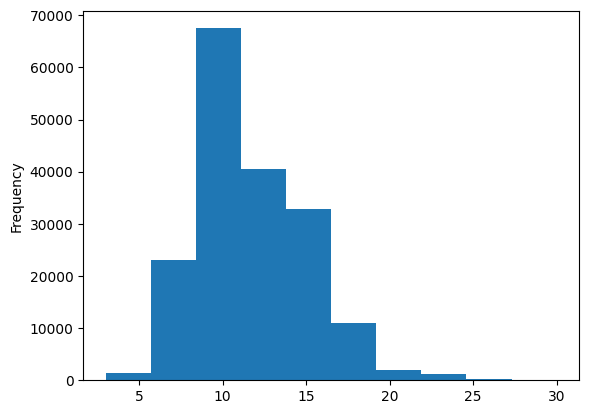

In [12]:
train_df.total_lines.plot(kind='hist')

In [13]:
train_sentences = train_df['text'].tolist()
val_sentences = val_df['text'].tolist()
test_sentences = test_df['text'].tolist()

train_sentences[:10]

['to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
 'secondary outcome measures included the western ontario and mcmaster universities osteoarthritis index scores , patient global assessment ( pga ) of the severity of knee oa , and @-min walk distance ( @mwd ) .',
 'serum levels of interleukin @ ( il-@ ) , il-@ , tumor necrosis factor ( tnf ) - , and high-sensitivity c-reactive protein ( hscrp ) were measured .',
 'there was a clinic

In [14]:
import sklearn as sklearn
sklearn.__version__

'1.6.1'

In [15]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(sparse_output=False)
train_labels_one_hot = one_hot_encoder.fit_transform(train_df[['target']].to_numpy())
val_labels_one_hot = one_hot_encoder.transform(val_df[['target']].to_numpy())
test_labels_one_hot = one_hot_encoder.transform(test_df[['target']].to_numpy())

train_labels_one_hot

array([[0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [16]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_df[['target']].to_numpy().ravel())
val_labels_encoded = label_encoder.transform(val_df[['target']].to_numpy().ravel())
test_labels_encoded = label_encoder.transform(test_df[['target']].to_numpy().ravel())

train_labels_encoded

array([3, 2, 2, ..., 4, 1, 1])

In [17]:
num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_
num_classes, class_names

(5,
 array(['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS'],
       dtype=object))

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

model_0 = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', MultinomialNB())
])

model_0.fit(
    X=train_sentences,
    y=train_labels_encoded
)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', MultinomialNB())])

In [19]:
model_0.score(
    X=val_sentences,
    y=val_labels_encoded
)

0.7218323844829869

In [20]:
baseline_preds = model_0.predict(val_sentences)
baseline_preds

array([4, 1, 3, ..., 4, 4, 1])

In [21]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py


--2026-05-12 13:03:47--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-05-12 13:03:48 (72.7 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [22]:
from helper_functions import calculate_results

baseline_results = calculate_results(
    y_true=val_labels_encoded,
    y_pred=baseline_preds
)
baseline_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

In [23]:
sent_lens = [len(sentence.split()) for sentence in train_sentences]
avg_sent_len = sum(sent_lens) / len(sent_lens)
avg_sent_len

26.338269273494777

(array([4.2075e+04, 8.3771e+04, 3.6877e+04, 1.0945e+04, 3.9310e+03,
        1.4450e+03, 5.6000e+02, 2.2600e+02, 1.0100e+02, 4.5000e+01,
        2.0000e+01, 1.2000e+01, 9.0000e+00, 1.0000e+01, 6.0000e+00,
        2.0000e+00, 3.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00]),
 array([  1.  ,  15.75,  30.5 ,  45.25,  60.  ,  74.75,  89.5 , 104.25,
        119.  , 133.75, 148.5 , 163.25, 178.  , 192.75, 207.5 , 222.25,
        237.  , 251.75, 266.5 , 281.25, 296.  ]),
 <BarContainer object of 20 artists>)

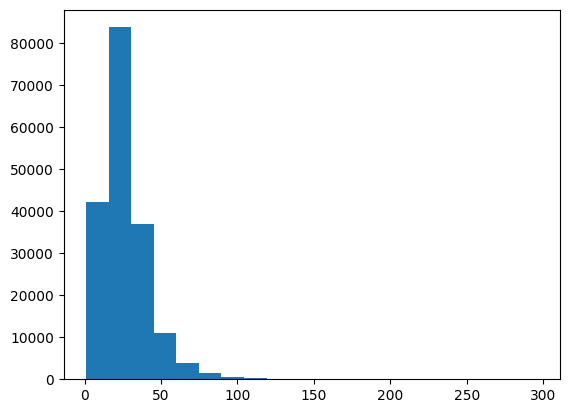

In [24]:
import matplotlib.pyplot as plt

plt.hist(sent_lens, bins=20)

In [25]:
import numpy as np
output_sen_len = int(np.percentile(sent_lens, 95))
output_sen_len

55

In [26]:
import tensorflow as tf

max_tokens = 68000
text_vectorizer = tf.keras.layers.TextVectorization(max_tokens=max_tokens, output_mode='int', output_sequence_length=output_sen_len)
text_vectorizer.adapt(train_sentences)

In [27]:
import random

target_sentence= random.choice(train_sentences)
print(f'Text:\n{target_sentence}')
print(f'\nLength of text: {len(target_sentence.split())}')
print(f'\nVectorized text:\n{text_vectorizer([target_sentence])}')

Text:
dopamine is the most commonly used first-line drug .

Length of text: 9

Vectorized text:
[[3701   20    2  215 1261   98 1368  300    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0]]


In [28]:
rct_20k_text_vocab = text_vectorizer.get_vocabulary()
print(f'Number of words in vocab: {len(rct_20k_text_vocab)}')
print(f'Most common words: {rct_20k_text_vocab[:10]}')
print(f'Least common words: {rct_20k_text_vocab[-10:]}')


Number of words in vocab: 64841
Most common words: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('of'), np.str_('in'), np.str_('to'), np.str_('with'), np.str_('a'), np.str_('were')]
Least common words: [np.str_('aarm'), np.str_('aaqol'), np.str_('aaq'), np.str_('aanhui'), np.str_('aana'), np.str_('aainduced'), np.str_('aaigroup'), np.str_('aachener'), np.str_('aachen'), np.str_('aaacp')]


In [29]:
token_embed = tf.keras.layers.Embedding(
    input_dim = len(rct_20k_text_vocab),
    output_dim = 128,
    mask_zero=True,
    name='token_embedding'
)

In [30]:
print(f'Sentence before vectorization: {target_sentence}')
print(f'Sentence after vectorization: {text_vectorizer([target_sentence])}')
print(f'Length of sentence before vectorization: {len(target_sentence.split())}')
print(f'Sentence after embedding: {token_embed(text_vectorizer([target_sentence]))}')
print(f'Shape of sentence after embedding: {token_embed(text_vectorizer([target_sentence])).shape}')

Sentence before vectorization: dopamine is the most commonly used first-line drug .
Sentence after vectorization: [[3701   20    2  215 1261   98 1368  300    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0]]
Length of sentence before vectorization: 9
Sentence after embedding: [[[-0.01621927 -0.00534849  0.02838041 ...  0.0410207  -0.03501297
    0.04095343]
  [ 0.01764588 -0.01434208 -0.03417045 ...  0.03802479 -0.01117524
   -0.030115  ]
  [ 0.01161621 -0.01589855 -0.01313063 ... -0.00027262 -0.04881908
    0.00292162]
  ...
  [ 0.0235872  -0.04893942  0.01676909 ... -0.00015748  0.04572567
    0.04129041]
  [ 0.0235872  -0.04893942  0.01676909 ... -0.00015748  0.04572567
    0.04129041]
  [ 0.0235872  -0.04893942  0.01676909 ... -0.00015748  0.04572567
    0.04129041]]]
Shape of sentence after em

In [31]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_sentences, train_labels_one_hot))
valid_dataset = tf.data.Dataset.from_tensor_slices((val_sentences, val_labels_one_hot))
test_dataset = tf.data.Dataset.from_tensor_slices((test_sentences, test_labels_one_hot))

train_dataset

<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(5,), dtype=tf.float64, name=None))>

In [32]:
import tensorflow as tf

# Re-create datasets from slices to ensure we don't 'double-batch'
train_dataset = tf.data.Dataset.from_tensor_slices((train_sentences, train_labels_one_hot))
valid_dataset = tf.data.Dataset.from_tensor_slices((val_sentences, val_labels_one_hot))
test_dataset = tf.data.Dataset.from_tensor_slices((test_sentences, test_labels_one_hot))

# Batch and prefetch
BATCH_SIZE = 32
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
valid_dataset = valid_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

display(train_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>

In [33]:
from tensorflow.keras import layers

inputs = layers.Input(shape=(1,), dtype=tf.string)
textvectors = text_vectorizer(inputs)
token_embeddings = token_embed(textvectors)
x = layers.Conv1D(filters=64, kernel_size=5, activation='relu')(token_embeddings)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model_1 = tf.keras.Model(inputs, outputs)

model_1.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 55)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_embedding (Embedding)     │ (None, 55, 128)        │     8,299,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 51, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,340,997 (31.82 MB)

 Trainable params: 8,340,997 (31.82 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history_model_1 = model_1.fit(
    train_dataset,
    epochs=3,
    steps_per_epoch=int(0.1*len(train_dataset)),
    validation_data=valid_dataset,
    validation_steps=int(0.1*len(valid_dataset))
)

Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.6246 - loss: 0.9414 - val_accuracy: 0.7204 - val_loss: 0.7312
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7382 - loss: 0.6966 - val_accuracy: 0.7537 - val_loss: 0.6710
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7591 - loss: 0.6502 - val_accuracy: 0.7699 - val_loss: 0.6255


In [35]:
model_1.evaluate(valid_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7743 - loss: 0.6258


[0.6257525682449341, 0.7742949724197388]

In [36]:
model_1_preds_probs = model_1.predict(valid_dataset)
model_1_preds_probs

945/945 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[3.89778107e-01, 1.95741832e-01, 1.12849414e-01, 2.71724939e-01,
        2.99056806e-02],
       [4.71558511e-01, 2.08457157e-01, 1.26576722e-02, 3.00601602e-01,
        6.72507426e-03],
       [2.21972585e-01, 2.33489200e-02, 4.18719649e-03, 7.50343740e-01,
        1.47493731e-04],
       ...,
       [4.56337875e-06, 1.18257687e-03, 5.26866643e-04, 3.14652948e-06,
        9.98282909e-01],
       [4.84123789e-02, 3.64748985e-01, 1.55844420e-01, 5.99780269e-02,
        3.71016204e-01],
       [2.45863289e-01, 4.66216445e-01, 1.15448505e-01, 6.30577281e-02,
        1.09413959e-01]], dtype=float32)

In [37]:
model_1_preds = tf.argmax(model_1_preds_probs, axis=1)
model_1_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 4, 1])>

In [38]:
model_1_results = calculate_results(
    y_true=val_labels_encoded,
    y_pred=model_1_preds
)
model_1_results

{'accuracy': 77.42949821263075,
 'precision': 0.7690390748303902,
 'recall': 0.7742949821263074,
 'f1': 0.7704860641762104}

In [39]:
import tensorflow_hub as hub
import tensorflow as tf
from tensorflow.keras import layers

class USEEmbeddingLayer(layers.Layer):
  def __init__(self, **kwargs):
    super(USEEmbeddingLayer, self).__init__(**kwargs)
    self.encoder = hub.KerasLayer(
        'https://tfhub.dev/google/universal-sentence-encoder/4',
        trainable=False
    )

  def call(self, inputs):
    return self.encoder(inputs)

tf_hub_embedding_layer = USEEmbeddingLayer(name='universal_sentence_encoder_wrapper')

In [40]:
print(f'Random sentence: {target_sentence}')
print(f'Length of sentence: {len(target_sentence.split())}')
#print(f'Embedded sentence: {tf_hub_embedding_layer([target_sentence])[0][:30]}')
#print(f'length of embedded sentence: {tf_hub_embedding_layer([target_sentence]).shape}')

Random sentence: dopamine is the most commonly used first-line drug .
Length of sentence: 9


In [41]:
inputs = layers.Input(shape=(), dtype=tf.string)
pretrained_embedding = tf_hub_embedding_layer(inputs)
x = layers.Dense(16, activation='relu')(pretrained_embedding)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model_2 = tf.keras.Model(inputs, outputs, name='model_2_USE_feature_extractor')

model_2.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [42]:
model_2.summary()

Model: "model_2_USE_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ universal_sentence_encoder_wra… │ (None, 512)            │             0 │
│ (USEEmbeddingLayer)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         8,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,293 (32.39 KB)

 Trainable params: 8,293 (32.39 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers


train_dataset = tf.data.Dataset.from_tensor_slices((train_sentences, train_labels_one_hot))
valid_dataset = tf.data.Dataset.from_tensor_slices((val_sentences, val_labels_one_hot))

BATCH_SIZE = 32
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
valid_dataset = valid_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

num_classes = 5


inputs = layers.Input(shape=(384,))
x = layers.Dense(128, activation='relu')(inputs)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model_2 = tf.keras.Model(inputs, outputs, name='model_2_sentence_transformer')

model_2.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)



In [44]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
train_embeddings=model.encode(train_sentences)
valid_embeddings=model.encode(val_sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [45]:
history_model_2 = model_2.fit(
    train_embeddings,
    train_labels_one_hot,
    epochs=3,
    batch_size=32,
    validation_data=(valid_embeddings, val_labels_one_hot)
)

Epoch 1/3
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.7101 - loss: 0.7560 - val_accuracy: 0.7386 - val_loss: 0.6877
Epoch 2/3
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - accuracy: 0.7496 - loss: 0.6613 - val_accuracy: 0.7533 - val_loss: 0.6483
Epoch 3/3
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.7657 - loss: 0.6230 - val_accuracy: 0.7618 - val_loss: 0.6293


In [46]:
model_2.summary()

Model: "model_2_sentence_transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,777 (585.07 KB)

 Trainable params: 49,925 (195.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 99,852 (390.05 KB)

In [47]:
model_2_pred_probs = model_2.predict(valid_embeddings)
model_2_preds = tf.argmax(model_2_pred_probs, axis=1)
model_2_results = calculate_results(
    y_true=val_labels_encoded,
    y_pred=model_2_preds)

945/945 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [48]:
model_2_results, model_1_results, baseline_results

({'accuracy': 76.17502978948762,
  'precision': 0.7557474633756597,
  'recall': 0.7617502978948762,
  'f1': 0.7553478530516363},
 {'accuracy': 77.42949821263075,
  'precision': 0.7690390748303902,
  'recall': 0.7742949821263074,
  'f1': 0.7704860641762104},
 {'accuracy': 72.1832384482987,
  'precision': 0.7186466952323352,
  'recall': 0.7218323844829869,
  'f1': 0.6989250353450294})

In [49]:
def split_chars(text):
  return ' '.join(list(text))

In [50]:
split_chars(random.choice(train_sentences))

'p a t i e n t s   w i t h   h e m i p a r e s i s   @   t o   @   m o n t h s   a f t e r   s t r o k e   w e r e   e n r o l l e d   i n   a   d o u b l e - b l i n d   ,   p l a c e b o - c o n t r o l l e d   ,   r a n d o m i z e d   c l i n i c a l   t r i a l   o f   r o p i n i r o l e   +   p h y s i c a l   t h e r a p y   v e r s u s   p l a c e b o   +   p h y s i c a l   t h e r a p y   ,   r e s u l t s   o f   w h i c h   h a v e   p r e v i o u s l y   b e e n   r e p o r t e d   (   n c t @   )   .'

In [51]:
train_chars = [split_chars(sentence) for sentence in train_sentences]
val_chars = [split_chars(sentence) for sentence in val_sentences]
test_chars = [split_chars(sentence) for sentence in test_sentences]

test_chars[:2]

['t h i s   s t u d y   a n a l y z e d   l i v e r   f u n c t i o n   a b n o r m a l i t i e s   i n   h e a r t   f a i l u r e   p a t i e n t s   a d m i t t e d   w i t h   s e v e r e   a c u t e   d e c o m p e n s a t e d   h e a r t   f a i l u r e   (   a d h f   )   .',
 'a   p o s t   h o c   a n a l y s i s   w a s   c o n d u c t e d   w i t h   t h e   u s e   o f   d a t a   f r o m   t h e   e v a l u a t i o n   s t u d y   o f   c o n g e s t i v e   h e a r t   f a i l u r e   a n d   p u l m o n a r y   a r t e r y   c a t h e t e r i z a t i o n   e f f e c t i v e n e s s   (   e s c a p e   )   .']

In [52]:
char_lens = [len(sentence ) for sentence in train_sentences]
mean_char_len = np.mean(char_lens)
mean_char_len

np.float64(149.3662574983337)

(array([2.2108e+04, 7.0583e+04, 5.3952e+04, 2.2391e+04, 7.4540e+03,
        2.2350e+03, 8.0200e+02, 2.8700e+02, 1.1800e+02, 4.9000e+01,
        2.9000e+01, 1.3000e+01, 8.0000e+00, 5.0000e+00, 1.0000e+00,
        2.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([1.00000e+00, 7.02500e+01, 1.39500e+02, 2.08750e+02, 2.78000e+02,
        3.47250e+02, 4.16500e+02, 4.85750e+02, 5.55000e+02, 6.24250e+02,
        6.93500e+02, 7.62750e+02, 8.32000e+02, 9.01250e+02, 9.70500e+02,
        1.03975e+03, 1.10900e+03, 1.17825e+03, 1.24750e+03, 1.31675e+03,
        1.38600e+03]),
 <BarContainer object of 20 artists>)

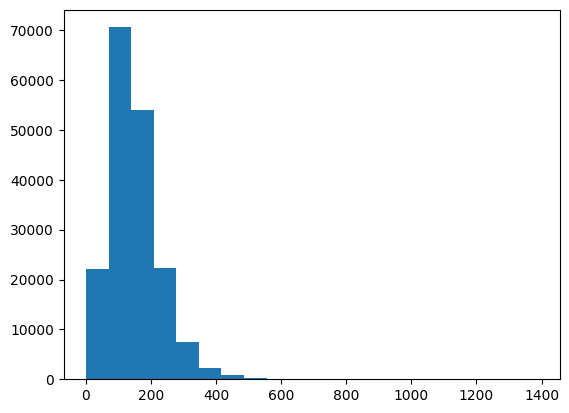

In [53]:
import matplotlib.pyplot as plt

plt.hist(char_lens, bins=20)

In [54]:
output_seq_char_len = int(np.percentile(char_lens, 95))
output_seq_char_len


290

In [55]:
import string

alphabet = string.ascii_lowercase + string.digits + string.punctuation
alphabet

'abcdefghijklmnopqrstuvwxyz0123456789!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [56]:
NUM_CHAR_TOKENS = len(alphabet) + 2
NUM_CHAR_TOKENS

70

In [57]:
char_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=NUM_CHAR_TOKENS,
    output_sequence_length=output_seq_char_len,
    name='char_vectorizer'
)

In [58]:
char_vectorizer.adapt(train_chars)

In [59]:
char_vocab = char_vectorizer.get_vocabulary()
char_vocab[:5], len(char_vocab)

(['', '[UNK]', np.str_('e'), np.str_('t'), np.str_('i')], 28)

In [60]:
char_embed = layers.Embedding(
    input_dim=NUM_CHAR_TOKENS,
    output_dim=64,
    mask_zero=False,
    name='char_embed'
)

In [61]:
split_chars(random.choice(train_sentences)), char_embed(char_vectorizer([split_chars(random.choice(train_sentences))])), char_embed(char_vectorizer([split_chars(random.choice(train_sentences))])).shape

('d e m a n d   i n t e n s i t y   (   c o n s u m p t i o n   a t   l o w   p r i c e s   )   w a s   u n r e l a t e d   t o   i n c o m e   c o n d i t i o n   a n d   r e m a i n e d   h i g h   a c r o s s   i n c o m e s   .',
 <tf.Tensor: shape=(1, 290, 64), dtype=float32, numpy=
 array([[[ 0.00225146, -0.02823416, -0.04674397, ..., -0.04113326,
          -0.01786508, -0.03939734],
         [ 0.03055963, -0.04798675,  0.01891268, ..., -0.01492419,
          -0.04758735,  0.01549094],
         [-0.01636759, -0.02080789, -0.01883816, ...,  0.03262528,
          -0.00573611,  0.00244086],
         ...,
         [-0.00906777, -0.0219589 ,  0.02239794, ...,  0.00868003,
           0.0250852 , -0.012782  ],
         [-0.00906777, -0.0219589 ,  0.02239794, ...,  0.00868003,
           0.0250852 , -0.012782  ],
         [-0.00906777, -0.0219589 ,  0.02239794, ...,  0.00868003,
           0.0250852 , -0.012782  ]]], dtype=float32)>,
 TensorShape([1, 290, 64]))

In [62]:
inputs = layers.Input(shape=(1,), dtype=tf.string)
char_vectors = char_vectorizer(inputs)
char_embeddings = char_embed(char_vectors)
x = layers.Conv1D(64, kernel_size=5, activation='relu')(char_embeddings)
x = layers.GlobalMaxPooling1D()(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model_3 = tf.keras.Model(inputs, outputs, name= 'model_3_conv1d_char_embeddings')

model_3.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [63]:
train_char_dataset= tf.data.Dataset.from_tensor_slices((train_chars, train_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)
val_char_dataset= tf.data.Dataset.from_tensor_slices((val_chars, val_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)
test_char_dataset= tf.data.Dataset.from_tensor_slices((test_chars, test_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)

In [64]:
history_model_3 = model_3.fit(
    train_char_dataset,
    epochs=3,
    steps_per_epoch=int(0.1*len(train_char_dataset)),
    validation_data=val_char_dataset,
    validation_steps=int(0.1*len(val_char_dataset))
)

Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5237 - loss: 1.1791 - val_accuracy: 0.6174 - val_loss: 0.9751
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6279 - loss: 0.9427 - val_accuracy: 0.6592 - val_loss: 0.8816
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6550 - loss: 0.8791 - val_accuracy: 0.6825 - val_loss: 0.8272


In [65]:
model_3_pred_probs = model_3.predict(val_char_dataset)
model_3_pred_probs

945/945 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


array([[0.08543339, 0.46817207, 0.0683348 , 0.35817808, 0.01988168],
       [0.09803473, 0.415159  , 0.02699202, 0.44745055, 0.01236358],
       [0.1361093 , 0.19129121, 0.09814745, 0.56475556, 0.00969647],
       ...,
       [0.02057128, 0.05788125, 0.16774163, 0.06501773, 0.68878806],
       [0.01245846, 0.03848696, 0.14324443, 0.01863201, 0.78717816],
       [0.32625243, 0.484436  , 0.14845023, 0.03674067, 0.0041207 ]],
      dtype=float32)

In [66]:
model_3_preds= tf.argmax(model_3_pred_probs, axis=1)
model_3_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([1, 3, 3, ..., 4, 4, 1])>

In [67]:
model_3_results = calculate_results(val_labels_encoded, model_3_preds)
model_3_results

{'accuracy': 67.47318946114127,
 'precision': 0.6766273574534041,
 'recall': 0.6747318946114127,
 'f1': 0.6659357432129389}

In [68]:
token_inputs= layers.Input(shape=(384,), name='token_inputs')
token_outputs = layers.Dense(128, activation='relu')(token_inputs)
token_model= tf.keras.Model(token_inputs, token_outputs)

char_inputs= layers.Input(shape=(1,), dtype=tf.string, name='char_inputs')
char_vectors = char_vectorizer(char_inputs)
char_embeddings = char_embed(char_vectors)
char_bi_lstm= layers.Bidirectional(layers.LSTM(24))(char_embeddings)
char_model= tf.keras.Model(char_inputs, char_bi_lstm)

token_char_concat= layers.Concatenate(name='token_char_hybrid')([token_model.output, char_model.output])

combined_dropout = layers.Dropout(0.5)(token_char_concat)
combined_dense = layers.Dense(128, activation='relu')(combined_dropout)
final_dropout = layers.Dropout(0.5)(combined_dense)
output_layer = layers.Dense(num_classes, activation='softmax')(final_dropout)

model_4 = tf.keras.Model(inputs=[token_model.input, char_model.input],
                         outputs=output_layer,
                         name='model_4_token_char_hybrid')



In [69]:
model_4.summary()

Model: "model_4_token_char_hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_inputs         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_vectorizer     │ (None, 290)       │          0 │ char_inputs[0][0] │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_inputs        │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embed          │ (None, 290, 64)   │      4,480 │ char_vectorizer[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     49,280 │ token_inputs[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 48)        │     17,088 │ char_embed[1][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_char_hybrid   │ (None, 176)       │          0 │ dense_6[0][0],    │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 176)       │          0 │ token_char_hybri… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     22,656 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 5)         │        645 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 94,149 (367.77 KB)

 Trainable params: 94,149 (367.77 KB)

 Non-trainable params: 0 (0.00 B)

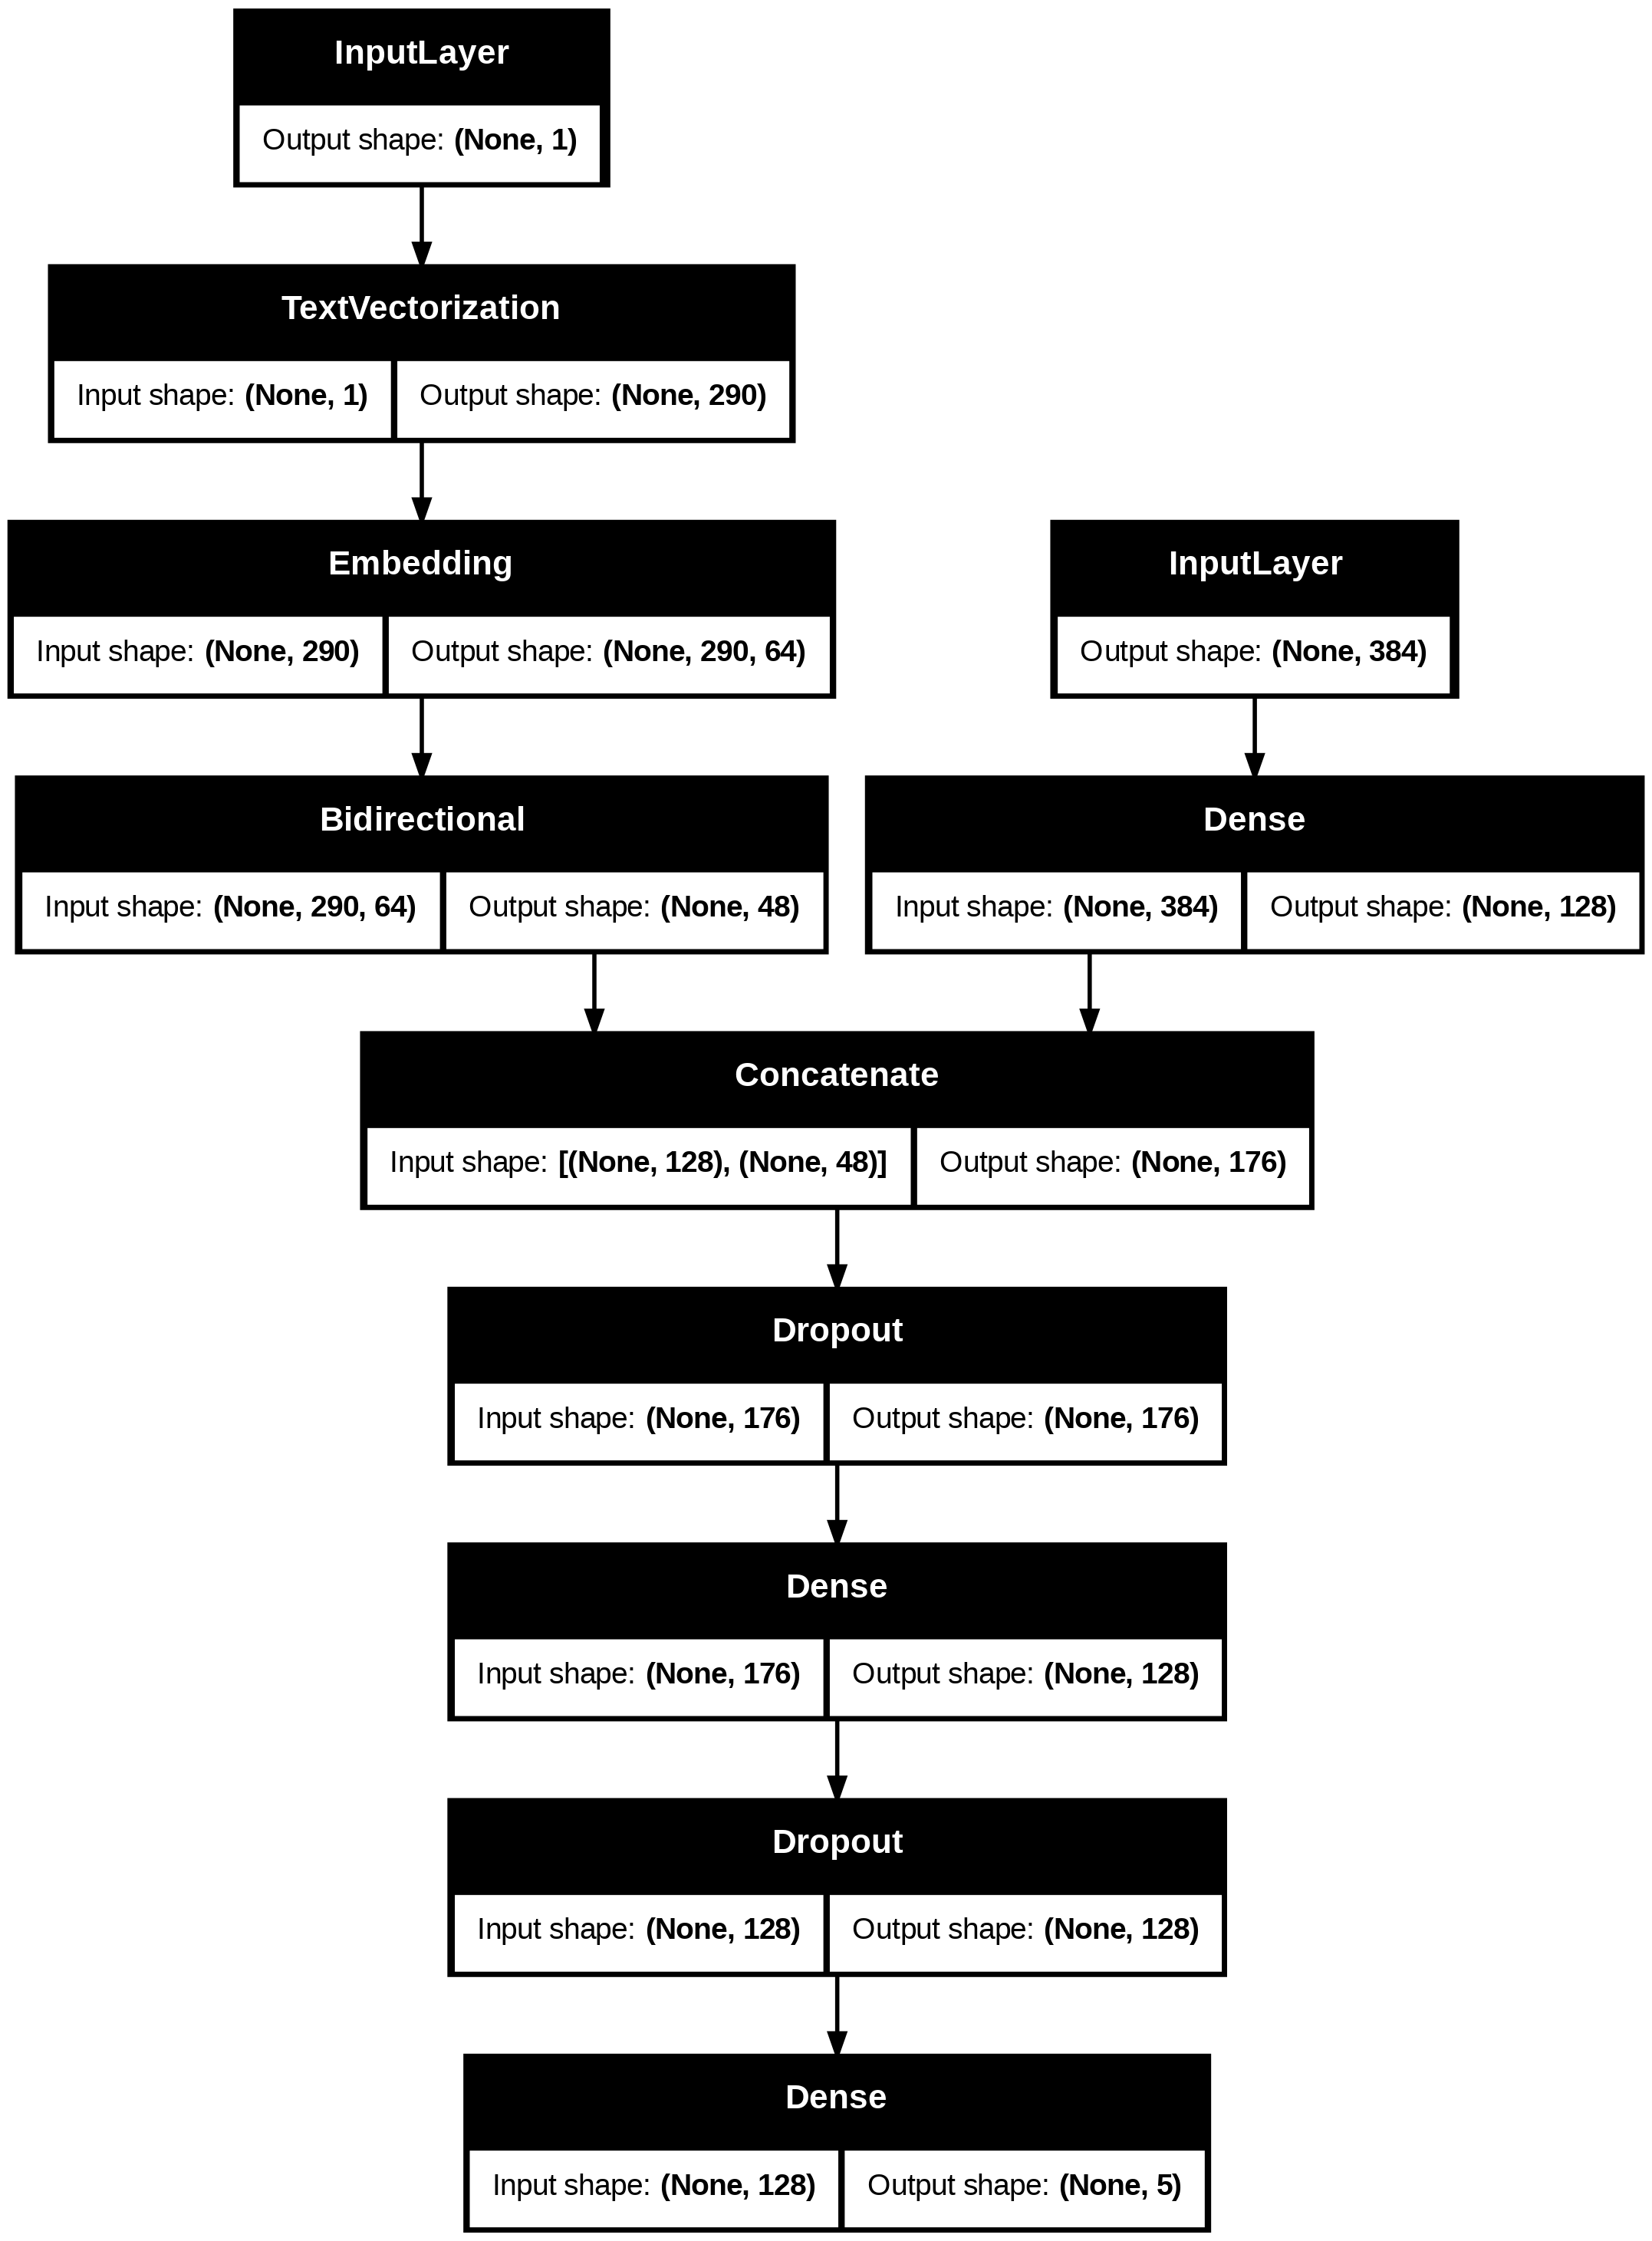

In [70]:
from keras.utils import plot_model

plot_model(model_4, show_shapes=True)

In [71]:
model_4.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [72]:
train_char_token_data = tf.data.Dataset.from_tensor_slices((train_embeddings, train_chars))
train_char_token_labels= tf.data.Dataset.from_tensor_slices(train_labels_one_hot)
train_char_token_dataset = tf.data.Dataset.zip((train_char_token_data, train_char_token_labels))

train_char_token_dataset = train_char_token_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [73]:
val_char_token_data = tf.data.Dataset.from_tensor_slices((valid_embeddings, val_chars))
val_char_token_labels= tf.data.Dataset.from_tensor_slices(val_labels_one_hot)
val_char_token_dataset = tf.data.Dataset.zip((val_char_token_data, val_char_token_labels))

val_char_token_dataset = val_char_token_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [74]:
history_model_4 = model_4.fit(
    train_char_token_dataset,
    epochs=3,
    steps_per_epoch=int(0.1*len(train_char_token_dataset)),
    validation_data=val_char_token_dataset,
    validation_steps=int(0.1*len(val_char_token_dataset))
)

Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.5898 - loss: 1.0284 - val_accuracy: 0.6975 - val_loss: 0.7845
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.6847 - loss: 0.8178 - val_accuracy: 0.7214 - val_loss: 0.7234
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.7015 - loss: 0.7850 - val_accuracy: 0.7417 - val_loss: 0.6842


In [75]:
model_4.evaluate(val_char_token_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.7357 - loss: 0.6897


[0.6896985769271851, 0.7357341647148132]

In [76]:
model_4_pred_probs= model_4.predict(val_char_token_dataset)
model_4_pred_probs

945/945 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step


array([[3.07143480e-01, 1.92219689e-01, 2.70410776e-01, 1.41092926e-01,
        8.91330987e-02],
       [9.30256024e-02, 7.12799311e-01, 7.75274076e-03, 7.05888718e-02,
        1.15833506e-01],
       [2.51579612e-01, 1.03045963e-01, 9.10469592e-02, 5.27539492e-01,
        2.67879684e-02],
       ...,
       [1.00956684e-04, 3.56313516e-03, 4.18205000e-02, 3.38121281e-05,
        9.54481542e-01],
       [1.69534683e-02, 6.74089789e-02, 4.25114036e-01, 1.19248284e-02,
        4.78598684e-01],
       [1.45772770e-01, 4.08612877e-01, 3.13628972e-01, 5.05400747e-02,
        8.14452916e-02]], dtype=float32)

In [77]:
model_4_preds = tf.argmax(model_4_pred_probs, axis=1)
model_4_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 1, 3, ..., 4, 4, 1])>

In [78]:
model_4_results = calculate_results(val_labels_encoded, model_4_preds)
model_4_results

{'accuracy': 73.57341453726995,
 'precision': 0.7296757417155904,
 'recall': 0.7357341453726995,
 'f1': 0.729222605833499}

In [79]:
train_df[:5]

,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11


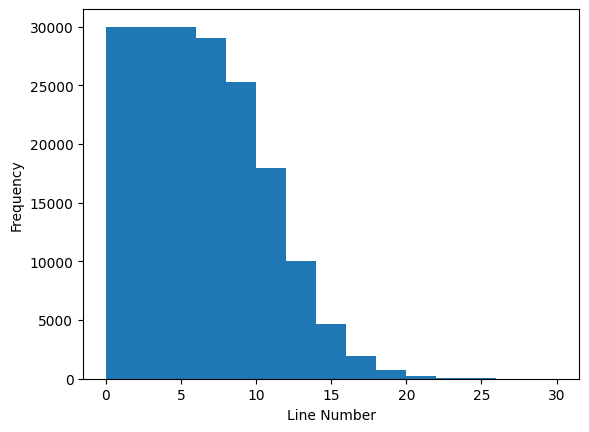

In [80]:
plt.hist(train_df['line_number'], bins=15)
plt.xlabel('Line Number')
plt.ylabel('Frequency')
plt.show()

In [108]:
train_line_numbers_one_hot = tf.squeeze(tf.one_hot(train_df[['line_number']].to_numpy(), depth=15))
val_line_numbers_one_hot = tf.squeeze(tf.one_hot(val_df[['line_number']].to_numpy(), depth=15))
test_line_numbers_one_hot = tf.squeeze(tf.one_hot(test_df[['line_number']].to_numpy(), depth=15))
train_line_numbers_one_hot[:14], train_line_numbers_one_hot.shape


(<tf.Tensor: shape=(14, 15), dtype=float32, numpy=
 array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0.

In [82]:
train_df['total_lines'].value_counts()

,count
total_lines,
11,24468
10,23639
12,22113
9,19400
13,18438
14,14610
8,12285
15,10768
7,7464


(array([ 1393., 23102., 67507., 40551., 32807., 11026.,  2051.,  1223.,
          291.,    89.]),
 array([ 3. ,  5.7,  8.4, 11.1, 13.8, 16.5, 19.2, 21.9, 24.6, 27.3, 30. ]),
 <BarContainer object of 10 artists>)

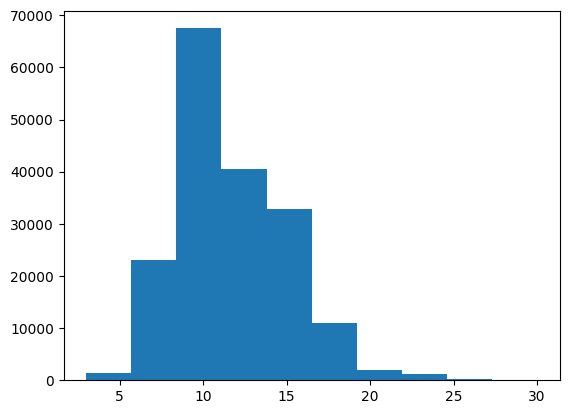

In [83]:
plt.hist(train_df['total_lines'])

In [84]:
np.percentile(train_df.total_lines, 98)

np.float64(20.0)

In [104]:
train_total_lines_one_hot = tf.squeeze(tf.one_hot(train_df[['total_lines']].to_numpy(), depth=20))
val_total_lines_one_hot = tf.squeeze(tf.one_hot(val_df[['total_lines']].to_numpy(), depth=20))
test_total_lines_one_hot = tf.squeeze(tf.one_hot(test_df[['total_lines']].to_numpy(), depth=20))
train_total_lines_one_hot[:14], train_total_lines_one_hot.shape

(<tf.Tensor: shape=(14, 20), dtype=float32, numpy=
 array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0

In [115]:
token_inputs = layers.Input(shape=(384,), name='token_inputs')
token_outputs = layers.Dense(128, activation='relu')(token_inputs)
token_model = tf.keras.Model(token_inputs, token_outputs)

char_inputs = layers.Input(shape=(1,), dtype=tf.string, name='char_inputs')
char_vectors = char_vectorizer(char_inputs)
char_embeddings = char_embed(char_vectors)
char_bi_lstm = layers.Bidirectional(layers.LSTM(24))(char_embeddings)
char_model = tf.keras.Model(char_inputs, char_bi_lstm)

line_number_inputs = layers.Input(shape=(15,), name='line_number_inputs')
line_number_outputs = layers.Dense(128, activation='relu')(line_number_inputs)
line_number_model = tf.keras.Model(line_number_inputs, line_number_outputs)

total_lines_inputs = layers.Input(shape=(20,), name='total_lines_inputs')
total_lines_outputs = layers.Dense(128, activation='relu')(total_lines_inputs)
total_lines_model = tf.keras.Model(total_lines_inputs, total_lines_outputs)

combined_embeddings = layers.Concatenate(name='char_token_hybrid_embeddings')([token_model.output, char_model.output])

z=layers.Dense(128, activation='relu')(combined_embeddings)
z=layers.Dropout(0.5)(z)

tribrid_embeddings = layers.Concatenate(name='tribrid_embeddings')([line_number_model.output, total_lines_model.output, z])

output_layer = layers.Dense(5, activation='softmax')(tribrid_embeddings)

model_5 = tf.keras.Model([line_number_inputs,
                          total_lines_inputs,
                          token_inputs,
                          char_inputs
                          ],
                         output_layer,
                         name='tribrid_embedding_model')

In [91]:
model_5.summary()

Model: "tribrid_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_inputs         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_vectorizer     │ (None, 290)       │          0 │ char_inputs[0][0] │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_inputs        │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embed          │ (None, 290, 64)   │      4,480 │ char_vectorizer[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 128)       │     49,280 │ token_inputs[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 48)        │     17,088 │ char_embed[4][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_token_hybrid_… │ (None, 176)       │          0 │ dense_19[0][0],   │
│ (Concatenate)       │                   │            │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ line_number_inputs  │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ total_lines_inputs  │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 128)       │     22,656 │ char_token_hybri… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 128)       │      2,048 │ line_number_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 128)       │      2,688 │ total_lines_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tribrid_embeddings  │ (None, 384)       │          0 │ dense_20[0][0],   │
│ (Concatenate)       │                   │            │ dense_21[0][0],   │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 5)         │      1,925 │ tribrid_embeddin… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 100,165 (391.27 KB)

 Trainable params: 100,165 (391.27 KB)

 Non-trainable params: 0 (0.00 B)

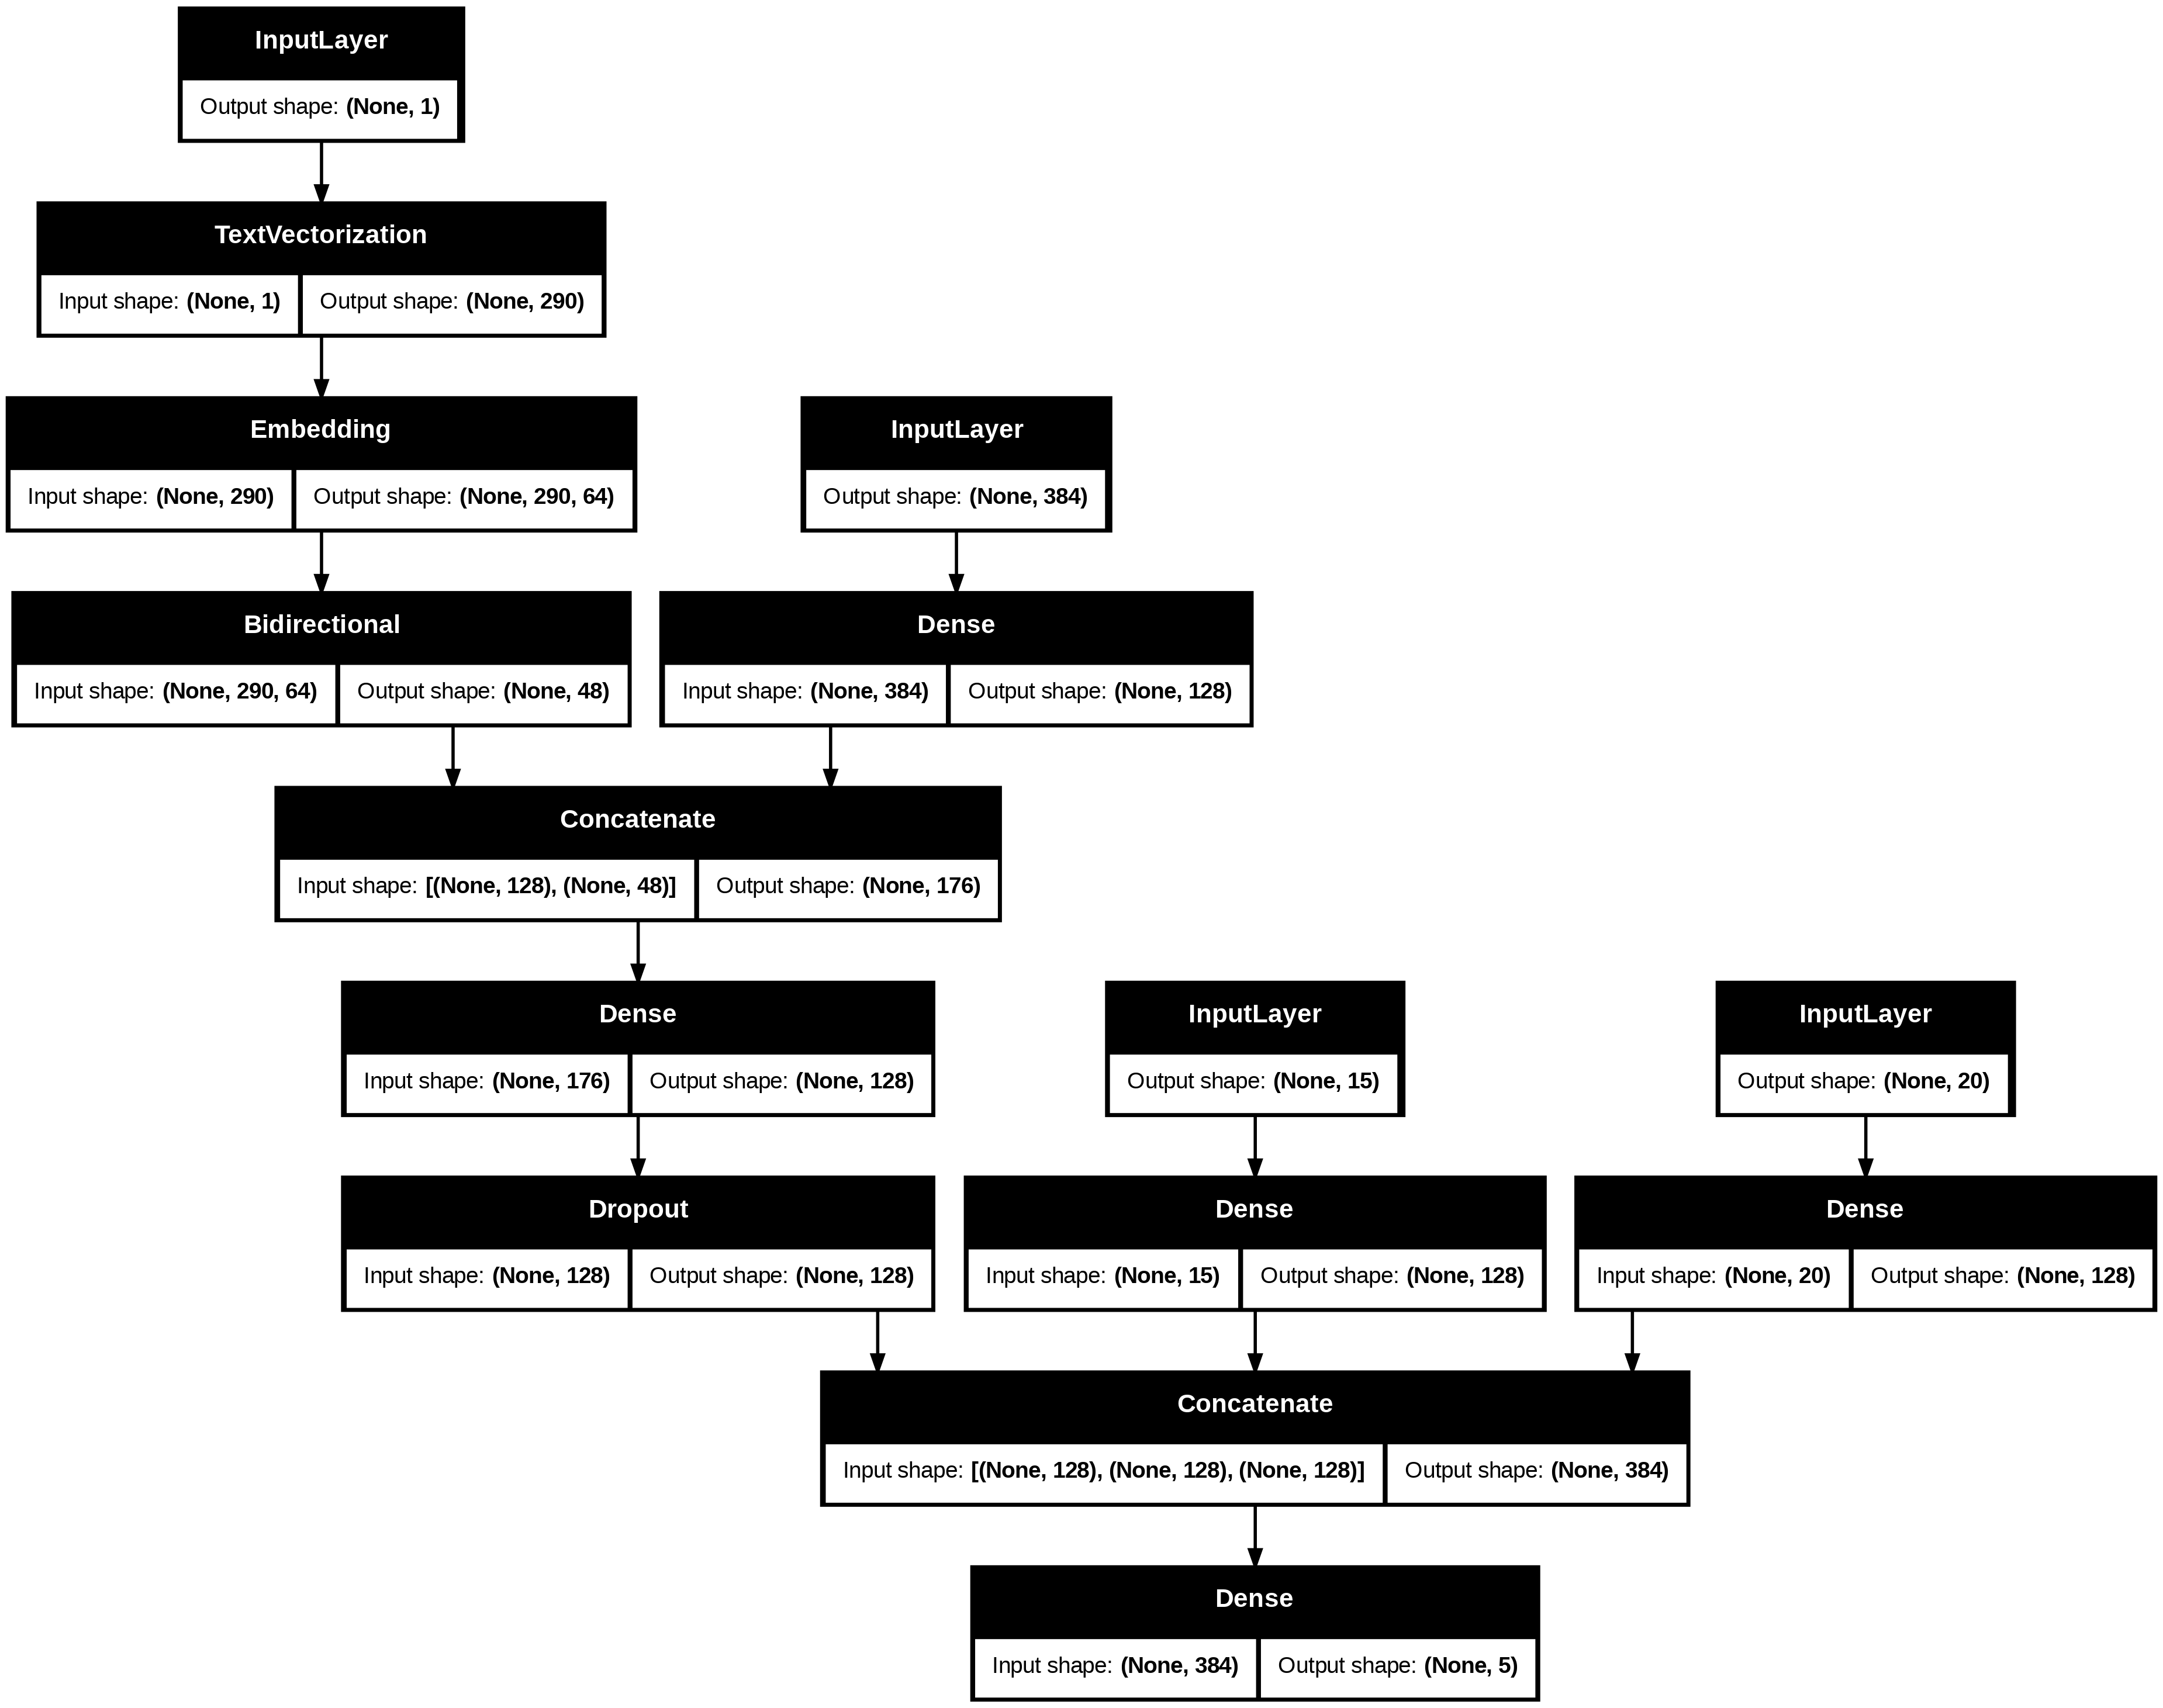

In [92]:
plot_model(model_5, show_shapes=True)

In [117]:
model_5.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [112]:
train_char_token_pos_data = tf.data.Dataset.from_tensor_slices((train_line_numbers_one_hot,
                                                                train_total_lines_one_hot,
                                                                  train_embeddings,
                                                                  train_chars))

train_char_token_pos_labels = tf.data.Dataset.from_tensor_slices((train_labels_one_hot))
train_char_token_pos_dataset = tf.data.Dataset.zip((train_char_token_pos_data, train_char_token_pos_labels))

train_char_token_pos_dataset = train_char_token_pos_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

val_char_token_pos_data = tf.data.Dataset.from_tensor_slices((val_line_numbers_one_hot,
                                                              val_total_lines_one_hot,
                                                              valid_embeddings,
                                                              val_chars))

val_char_token_pos_labels = tf.data.Dataset.from_tensor_slices((val_labels_one_hot))
val_char_token_pos_dataset = tf.data.Dataset.zip((val_char_token_pos_data, val_char_token_pos_labels))

val_char_token_pos_dataset = val_char_token_pos_dataset.batch(32).prefetch(tf.data.AUTOTUNE)


In [113]:
train_char_token_pos_dataset, val_char_token_pos_dataset

(<_PrefetchDataset element_spec=((TensorSpec(shape=(None, 15), dtype=tf.float32, name=None), TensorSpec(shape=(None, 20), dtype=tf.float32, name=None), TensorSpec(shape=(None, 384), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.string, name=None)), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>,
 <_PrefetchDataset element_spec=((TensorSpec(shape=(None, 15), dtype=tf.float32, name=None), TensorSpec(shape=(None, 20), dtype=tf.float32, name=None), TensorSpec(shape=(None, 384), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.string, name=None)), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>)

In [118]:
history_model_5 = model_5.fit(
    train_char_token_pos_dataset,
    epochs=3,
    steps_per_epoch=int(0.1*len(train_char_token_pos_dataset)),
    validation_data=val_char_token_pos_dataset,
    validation_steps=int(0.1*len(val_char_token_pos_dataset))
)

Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.7317 - loss: 1.0860 - val_accuracy: 0.8148 - val_loss: 0.9701
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - accuracy: 0.8187 - loss: 0.9653 - val_accuracy: 0.8278 - val_loss: 0.9507
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.8268 - loss: 0.9489 - val_accuracy: 0.8388 - val_loss: 0.9315


In [119]:
model_5_pred_probs = model_5.predict(
    val_char_token_pos_dataset
)

945/945 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step


In [120]:
model_5_preds = tf.argmax(model_5_pred_probs, axis=1)
model_5_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 4, 1])>

In [121]:
model_5_results=calculate_results(val_labels_encoded, model_5_preds)
model_5_results

{'accuracy': 83.86402753872633,
 'precision': 0.8362784874683652,
 'recall': 0.8386402753872634,
 'f1': 0.8370328907117741}

In [126]:
all_model_results = pd.DataFrame({
    'baseline': baseline_results,
    'model_1_custom_embedding': model_1_results,
    'model_2_sentence_transformer': model_2_results,
    'model_3_conv1d_char_embeddings': model_3_results,
    'model_4_token_char_hybrid': model_4_results,
    'model_5_tribrid_embedding': model_5_results
})
all_model_results = all_model_results.transpose()
all_model_results

,accuracy,precision,recall,f1
baseline,72.183238,0.718647,0.721832,0.698925
model_1_custom_embedding,77.429498,0.769039,0.774295,0.770486
model_2_sentence_transformer,76.175030,0.755747,0.761750,0.755348
model_3_conv1d_char_embeddings,67.473189,0.676627,0.674732,0.665936
model_4_token_char_hybrid,73.573415,0.729676,0.735734,0.729223
model_5_tribrid_embedding,83.864028,0.836278,0.838640,0.837033


In [127]:
all_model_results['accuracy']=all_model_results['accuracy']/100
all_model_results

,accuracy,precision,recall,f1
baseline,0.721832,0.718647,0.721832,0.698925
model_1_custom_embedding,0.774295,0.769039,0.774295,0.770486
model_2_sentence_transformer,0.761750,0.755747,0.761750,0.755348
model_3_conv1d_char_embeddings,0.674732,0.676627,0.674732,0.665936
model_4_token_char_hybrid,0.735734,0.729676,0.735734,0.729223
model_5_tribrid_embedding,0.838640,0.836278,0.838640,0.837033


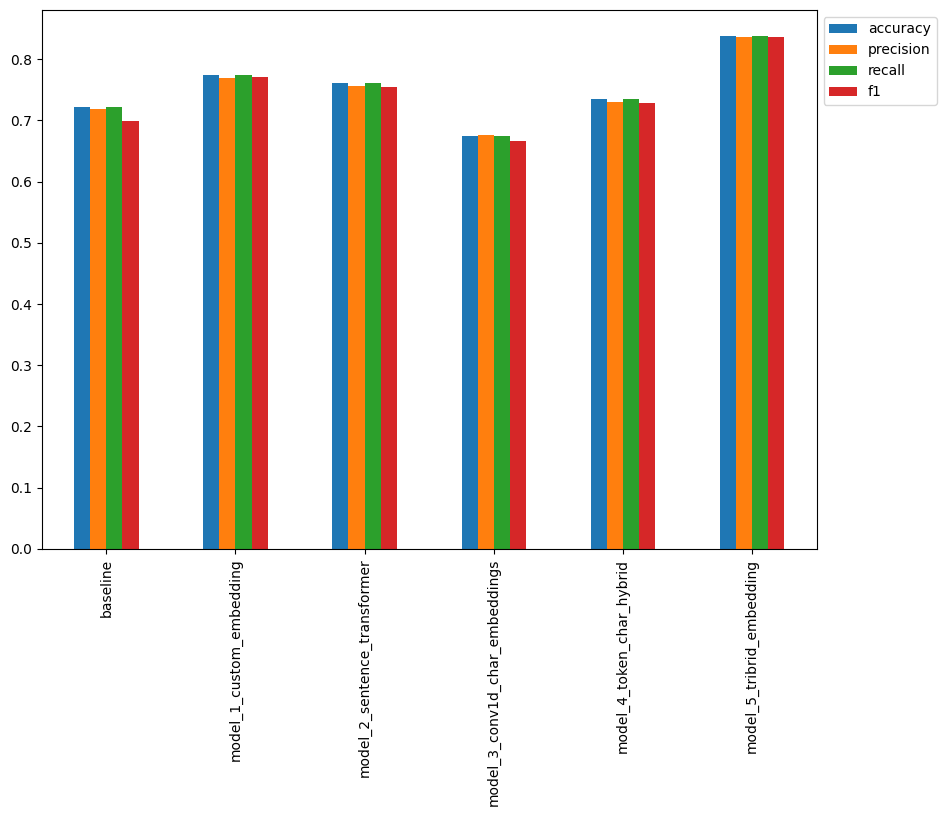

In [128]:
all_model_results.plot(kind='bar', figsize=(10,7)).legend(bbox_to_anchor=(1.0,1.0))


<Axes: >

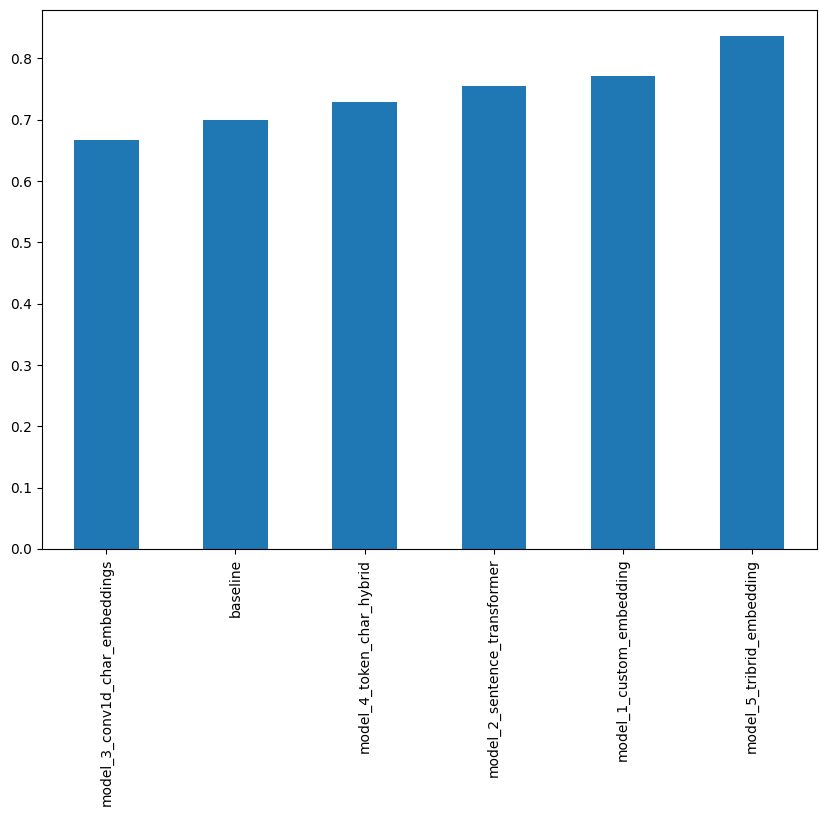

In [130]:
all_model_results.sort_values('f1', ascending=True)['f1'].plot(kind='bar', figsize=(10,7))

In [132]:
model_5.save('skimlit_model.keras')


In [133]:
loaded_model = tf.keras.models.load_model('skimlit_model.keras')
loaded_model_results = calculate_results(val_labels_encoded, tf.argmax(loaded_model.predict(val_char_token_pos_dataset), axis=1))
loaded_model_results

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 19 variables whereas the saved optimizer has 36 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


945/945 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step


{'accuracy': 83.86402753872633,
 'precision': 0.8362784874683652,
 'recall': 0.8386402753872634,
 'f1': 0.8370328907117741}

In [136]:
model_5_results

{'accuracy': 83.86402753872633,
 'precision': 0.8362784874683652,
 'recall': 0.8386402753872634,
 'f1': 0.8370328907117741}

In [137]:
test_embeddings=model.encode(test_sentences)

In [138]:
test_char_token_pos_data = tf.data.Dataset.from_tensor_slices((test_line_numbers_one_hot,
                                                              test_total_lines_one_hot,
                                                              test_embeddings,
                                                              test_chars))

test_char_token_pos_labels = tf.data.Dataset.from_tensor_slices((test_labels_one_hot))
test_char_token_pos_dataset = tf.data.Dataset.zip((test_char_token_pos_data, test_char_token_pos_labels))

test_char_token_pos_dataset = test_char_token_pos_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [140]:
loaded_model_test_results = calculate_results(test_labels_encoded, tf.argmax(loaded_model.predict(test_char_token_pos_dataset), axis=1))
loaded_model_test_results

942/942 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step


{'accuracy': 83.20889331342293,
 'precision': 0.8295332463697622,
 'recall': 0.8320889331342293,
 'f1': 0.8304743497554288}